# T2 — The geography of the divergence

**Question:** *Is the wage / income stagnation a Mezzogiorno problem only, or have rich Northern Italian regions also fallen behind comparable European regions?*

**Goal:** test empirically the hypothesis that *all* Italian regions — including the rich ones (Lombardia, Emilia-Romagna, Veneto) — have lost ground in relative terms vs European peers between 2000 and 2024.

**Expected output:**
- a tidy region-level panel ready for the final visualisation,
- a clear answer (yes / no / it depends) on the hypothesis above,
- the design choice for Visualisation #2 in the final dashboard (paired choropleth in Tableau or Power BI), justified by what the EDA shows.

**Countries in scope:** Italy + Germany + France + Spain. EA20 average as benchmark.

## 1. Setup — libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"

DATA_DIR = Path("data/task_2")
OUT_DIR  = Path("data/task_2"); OUT_DIR.mkdir(exist_ok=True)
DATA_DIR.resolve()

PosixPath('/sessions/festive-great-ritchie/mnt/Data Visualization/Data-visualization-project/data/task_2')

## 2. Build cleaned panel from Eurostat raw download

The raw Eurostat custom export (`regional_gdp_pps_absolute_eurostat_2000_2024.csv`,
1 775 rows) is filtered to the 70-code whitelist documented in `SOURCES.md`:
21 Italian regioni (NUTS 2), 16 German Länder (NUTS 1), 13 French régions
post-2016 (NUTS 1), 19 Spanish comunidades (NUTS 2), and the EA20
benchmark. The Euro-area aggregate `EA20` is dropped — the project uses
EA20 as the consistent EU-level reference for the choropleth.

The cleaning step is kept in the notebook for full reproducibility:
re-running this cell from the raw download produces an identical
`panel_t2_regional_gdp_2000_2024.csv`.

In [2]:
RAW_PATH   = DATA_DIR / "regional_gdp_pps_absolute_eurostat_2000_2024.csv"
PANEL_PATH = OUT_DIR  / "panel_t2_regional_gdp_2000_2024.csv"

# Country-specific NUTS-level whitelist (see SOURCES.md Â§ Cleaning step)
WHITELIST = {
    "Italy":   ["ITC1","ITC2","ITC3","ITC4","ITF1","ITF2","ITF3","ITF4","ITF5","ITF6",
                "ITG1","ITG2","ITH1","ITH2","ITH3","ITH4","ITH5","ITI1","ITI2","ITI3","ITI4"],
    "Germany": ["DE1","DE2","DE3","DE4","DE5","DE6","DE7","DE8","DE9",
                "DEA","DEB","DEC","DED","DEE","DEF","DEG"],
    "France":  ["FR1","FRB","FRC","FRD","FRE","FRF","FRG","FRH","FRI","FRJ","FRK","FRL","FRM"],
    "Spain":   ["ES11","ES12","ES13","ES21","ES22","ES23","ES24","ES30","ES41","ES42","ES43",
                "ES51","ES52","ES53","ES61","ES62","ES63","ES64","ES70"],
    "EA20":    ["EA20"],
}
code_to_country = {code: country for country, codes in WHITELIST.items() for code in codes}

raw = pd.read_csv(RAW_PATH)

panel = (
    raw[["geo", "Geopolitical entity (reporting)", "TIME_PERIOD", "OBS_VALUE"]]
        .rename(columns={"geo": "code",
                         "Geopolitical entity (reporting)": "region",
                         "TIME_PERIOD": "year",
                         "OBS_VALUE": "pps_per_capita"})
        .query("code in @code_to_country")
        .assign(country=lambda d: d["code"].map(code_to_country))
        .sort_values(["country", "code", "year"])
        .reset_index(drop=True)
)

panel.to_csv(PANEL_PATH, index=False)

print(f"Loaded raw: {raw.shape}")
print(f"Cleaned panel: {panel.shape}  ({panel['code'].nunique()} codes Ã {panel['year'].nunique()} years)")
print(f"By country: {panel.groupby('country')['code'].nunique().to_dict()}")
print(f"Saved: {PANEL_PATH}")
panel.head()

Loaded raw: (1775, 17)
Cleaned panel: (1750, 5)  (70 codes Ã 25 years)
By country: {'EA20': 1, 'France': 13, 'Germany': 16, 'Italy': 21, 'Spain': 19}
Saved: data/task_2/panel_t2_regional_gdp_2000_2024.csv


,code,region,year,pps_per_capita,country
0,EA20,Euro area – 20 countries (from 2023),2000,21000,EA20
1,EA20,Euro area – 20 countries (from 2023),2001,21900,EA20
2,EA20,Euro area – 20 countries (from 2023),2002,22500,EA20
3,EA20,Euro area – 20 countries (from 2023),2003,23000,EA20
4,EA20,Euro area – 20 countries (from 2023),2004,23800,EA20


## 3. Normalise — compute `pct_ea20` per region-year

We merge the EA20 absolute value into every row of the same year and divide. After the merge the EA20 row is dropped from `regions` (it is constantly 100 by construction and is not informative for the regional comparison).

In [3]:
ea20 = (
    panel[panel["code"] == "EA20"][["year", "pps_per_capita"]]
    .rename(columns={"pps_per_capita": "ea20_avg"})
)

panel = panel.merge(ea20, on="year", how="left")
panel["pct_ea20"] = panel["pps_per_capita"] / panel["ea20_avg"] * 100

regions = panel[panel["country"] != "EA20"].copy()

# Quick check: EA20 should be flat at 100 across all years
ea20_check = panel[panel["code"] == "EA20"][["year", "pct_ea20"]]
print(f"EA20 sanity (should all be 100): min={ea20_check['pct_ea20'].min():.1f}, max={ea20_check['pct_ea20'].max():.1f}")
print(f"Regions panel: {regions.shape}  |  Codes: {regions['code'].nunique()}")
regions.head()

EA20 sanity (should all be 100): min=100.0, max=100.0
Regions panel: (1725, 7)  |  Codes: 69


,code,region,year,pps_per_capita,country,ea20_avg,pct_ea20
25,FR1,Ile de France,2000,34200,France,21000,162.857143
26,FR1,Ile de France,2001,35600,France,21900,162.557078
27,FR1,Ile de France,2002,36800,France,22500,163.555556
28,FR1,Ile de France,2003,36200,France,23000,157.391304
29,FR1,Ile de France,2004,36700,France,23800,154.201681


## 4. Region panel — focal regions and narrative pairs

For visual emphasis we identify a small set of **paired regions** that share comparable economic profiles in 2000 — the start year. Following the methodology debate (see `data/task_2/SOURCES.md`), we keep five pairs whose 2000 values are close enough to make a fair comparison; the Lazio ↔ Île-de-France pair is dropped because the two regions had a wide gap already in 2000 (~50 pp).

| Italian region | NUTS code | European peer | NUTS code |
|---|---|---|---|
| Lombardia | ITC4 | Bayern | DE2 |
| Emilia-Romagna | ITH5 | Baden-Württemberg | DE1 |
| Veneto | ITH3 | Auvergne-Rhône-Alpes | FRK |
| Sicilia | ITG1 | Andalucía | ES61 |
| Campania | ITF3 | Extremadura | ES43 |

In [4]:
pairs = pd.DataFrame(
    [
        ("Lombardia",       "ITC4", "Bayern",                   "DE2",  "Manufacturing core"),
        ("Emilia-Romagna",  "ITH5", "Baden-Württemberg",        "DE1",  "Industrial / export"),
        ("Veneto",          "ITH3", "Auvergne-Rhône-Alpes",     "FRK",  "Mid-sized industrial"),
        ("Sicilia",         "ITG1", "Andalucía",                "ES61", "Southern, agriculture / tourism"),
        ("Campania",        "ITF3", "Extremadura",              "ES43", "Southern, low GDP per capita"),
    ],
    columns=["italian_region", "italian_code", "peer_region", "peer_code", "rationale"],
)
pairs

,italian_region,italian_code,peer_region,peer_code,rationale
0,Lombardia,ITC4,Bayern,DE2,Manufacturing core
1,Emilia-Romagna,ITH5,Baden-Württemberg,DE1,Industrial / export
2,Veneto,ITH3,Auvergne-Rhône-Alpes,FRK,Mid-sized industrial
3,Sicilia,ITG1,Andalucía,ES61,"Southern, agriculture / tourism"
4,Campania,ITF3,Extremadura,ES43,"Southern, low GDP per capita"


## 5. Sanity check — paired regions in % EA20 (2000 vs 2024)

Now that the metric is normalised, we can read the table directly: in 2000 region X was at *N %* of the EA20 average; in 2024 it is at *M %*; the change `Δpp = M − N` is the relative gain (+) or loss (−).

If the hypothesis ("Italian regions — even the rich ones — lost ground vs European peers") holds, every Italian row should show a **negative Δpp**, with the peer's Δpp closer to zero or positive.

In [5]:
def value_at(code: str, year: int, col: str = "pct_ea20"):
    sub = regions[(regions["code"] == code) & (regions["year"] == year)]
    return None if sub.empty else float(sub[col].iloc[0])

print(f"{'Pair':46s} {'2000':>8s} {'2024':>8s} {'Δpp':>8s}")
print("-" * 78)
for _, r in pairs.iterrows():
    it_2000 = value_at(r["italian_code"], 2000)
    it_2024 = value_at(r["italian_code"], 2024)
    pe_2000 = value_at(r["peer_code"],    2000)
    pe_2024 = value_at(r["peer_code"],    2024)
    print(f"{r['italian_region']:24s} ({r['italian_code']:5s})       {it_2000:>7.0f} {it_2024:>7.0f}   {it_2024-it_2000:>+5.0f}")
    print(f"  └ {r['peer_region']:22s} ({r['peer_code']:5s})       {pe_2000:>7.0f} {pe_2024:>7.0f}   {pe_2024-pe_2000:>+5.0f}")
    gap_2000 = it_2000 - pe_2000
    gap_2024 = it_2024 - pe_2024
    print(f"     Italian region vs peer:   gap 2000 = {gap_2000:+.0f} pp,  gap 2024 = {gap_2024:+.0f} pp,  swing = {gap_2024-gap_2000:+.0f} pp")
    print()

Pair                                               2000     2024      Δpp
------------------------------------------------------------------------------
Lombardia                (ITC4 )           145     126     -18
  └ Bayern                 (DE2  )           125     129      +5
     Italian region vs peer:   gap 2000 = +20 pp,  gap 2024 = -3 pp,  swing = -23 pp

Emilia-Romagna           (ITH5 )           132     112     -21
  └ Baden-Württemberg      (DE1  )           126     125      -1
     Italian region vs peer:   gap 2000 = +6 pp,  gap 2024 = -13 pp,  swing = -20 pp

Veneto                   (ITH3 )           122     104     -18
  └ Auvergne-Rhône-Alpes   (FRK  )           101      93      -9
     Italian region vs peer:   gap 2000 = +21 pp,  gap 2024 = +12 pp,  swing = -9 pp

Sicilia                  (ITG1 )            67      59      -8
  └ Andalucía              (ES61 )            63      66      +2
     Italian region vs peer:   gap 2000 = +4 pp,  gap 2024 = -7 pp,  swing = 

## 6. EDA — Italian regions: Δpp 2000 → 2024

For each Italian region we compute the change in % of EA20 between 2000 and 2024, in **percentage points (pp)**. Negative = relative divergence (lost ground vs the EU average); positive = relative convergence.

In [6]:
def make_change_table(df: pd.DataFrame, start_year: int = 2000, end_year: int = 2024) -> pd.DataFrame:
    starts = (df[df["year"] == start_year][["code", "region", "country", "pct_ea20"]]
              .rename(columns={"pct_ea20": f"y{start_year}"}))
    ends = (df[df["year"] == end_year][["code", "pct_ea20"]]
            .rename(columns={"pct_ea20": f"y{end_year}"}))
    out = starts.merge(ends, on="code")
    out["delta_pp"] = out[f"y{end_year}"] - out[f"y{start_year}"]
    return out

change_table = make_change_table(regions).sort_values("delta_pp")
italy_change = change_table[change_table["country"] == "Italy"].sort_values("delta_pp")

print("Italian regions: change in % EA20 average, 2000 → 2024 (pp)\n")
print(italy_change[["code", "region", "y2000", "y2024", "delta_pp"]].round(1).to_string(index=False))

n_negative = (italy_change["delta_pp"] < 0).sum()
print(f"\nItalian regions with negative Δpp (lost ground vs EU avg): {n_negative} / {len(italy_change)}")
print(f"Worst Italian Δpp : {italy_change['delta_pp'].min():+.0f} pp")
print(f"Best  Italian Δpp : {italy_change['delta_pp'].max():+.0f} pp")
print(f"Median Italian Δpp: {italy_change['delta_pp'].median():+.1f} pp")

Italian regions: change in % EA20 average, 2000 → 2024 (pp)

code                              region  y2000  y2024  delta_pp
ITI4                               Lazio  134.8  108.2     -26.6
ITI2                              Umbria  103.8   81.5     -22.3
ITH2        Provincia Autonoma di Trento  141.9  119.7     -22.2
ITC2        Valle d’Aosta/Vallée d’Aoste  141.0  119.7     -21.3
ITH5                      Emilia-Romagna  132.4  111.8     -20.6
ITC4                           Lombardia  144.8  126.4     -18.4
ITH3                              Veneto  122.4  104.1     -18.3
ITC1                            Piemonte  114.3   96.9     -17.4
ITH4               Friuli-Venezia Giulia  114.8   97.8     -16.9
ITI1                             Toscana  113.8   98.3     -15.5
ITI3                              Marche  101.0   85.6     -15.3
ITC3                             Liguria  112.9   98.1     -14.8
ITF2                              Molise   83.8   69.5     -14.3
ITF1                         

## 7. EDA — bar chart of Italian regional changes (Δpp)

The same data, plotted. Bars sorted ascending: most-divergent on top, most-convergent on bottom. Red = lost ground (Δpp < 0); green = gained or held (Δpp ≥ 0). The vertical reference at 0 marks "no change in relative position vs the EA20 average".

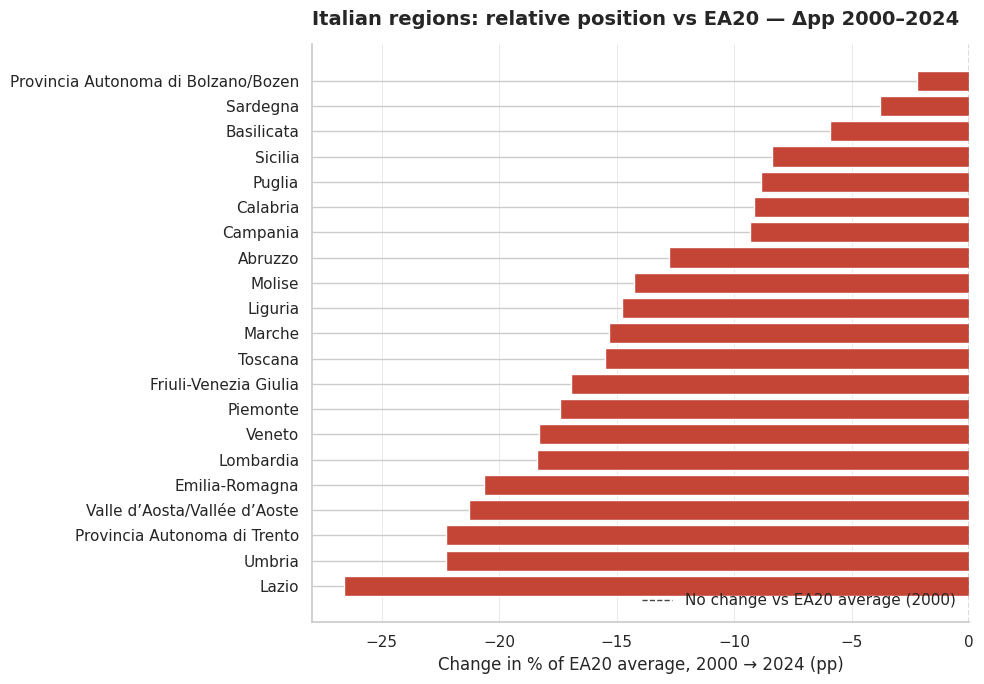

In [7]:
italy_change_sorted = italy_change.sort_values("delta_pp")

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#c44536" if d < 0 else "#5a8c5e" for d in italy_change_sorted["delta_pp"]]
ax.barh(italy_change_sorted["region"], italy_change_sorted["delta_pp"], color=colors, edgecolor="white")
ax.axvline(0, color="#444", lw=1, ls="--", label="No change vs EA20 average (2000)")
ax.legend(loc="lower right", frameon=False)
ax.set_xlabel("Change in % of EA20 average, 2000 → 2024 (pp)")
ax.set_title("Italian regions: relative position vs EA20 — Δpp 2000–2024",
             loc="left", fontsize=14, pad=14)
ax.grid(axis="x", color="#e0e0e0", lw=0.5)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

## 8. EDA — distribution of Δpp by country

Box + strip plot of the region-level Δpp (in pp) by country. With the metric now properly normalised, **0 means "the country's regions, on average, kept their position vs the EA20"**. A box clearly to the left of 0 = the country's regions, as a group, lost ground; to the right = gained.

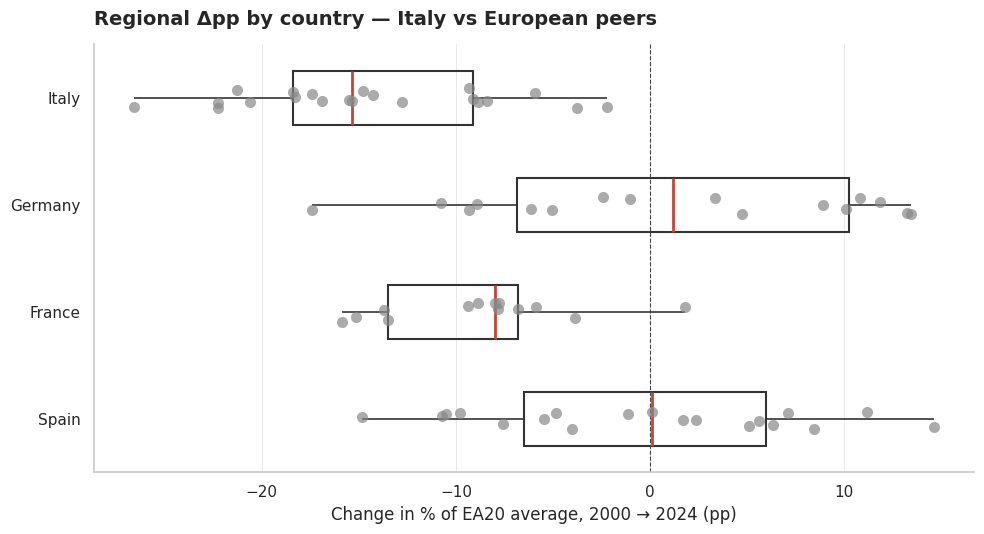


Median Δpp by country (pp):
country
France     -8.0
Germany     1.2
Italy     -15.3
Spain       0.1

Fraction of regions with negative Δpp by country:
country
France     0.92
Germany    0.50
Italy      1.00
Spain      0.47


In [8]:
countries_in_scope = ["Italy", "Germany", "France", "Spain"]
plot_df = change_table[change_table["country"].isin(countries_in_scope)].copy()
plot_df["country"] = pd.Categorical(plot_df["country"], categories=countries_in_scope, ordered=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.stripplot(data=plot_df, x="delta_pp", y="country", color="#888", alpha=0.7, size=8, ax=ax)
sns.boxplot(data=plot_df, x="delta_pp", y="country", showcaps=False, width=0.5,
            boxprops={"facecolor": "none", "edgecolor": "#333", "linewidth": 1.5},
            whiskerprops={"color": "#333", "linewidth": 1.2},
            medianprops={"color": "#c44536", "linewidth": 2}, fliersize=0, ax=ax)
ax.axvline(0, color="#444", lw=0.8, ls="--")
ax.set_xlabel("Change in % of EA20 average, 2000 → 2024 (pp)")
ax.set_ylabel("")
ax.set_title("Regional Δpp by country — Italy vs European peers",
             loc="left", fontsize=14, pad=14)
ax.grid(axis="x", color="#e0e0e0", lw=0.5)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

print("\nMedian Δpp by country (pp):")
print(change_table.groupby("country")["delta_pp"].median().round(1).to_string())
print("\nFraction of regions with negative Δpp by country:")
print((change_table.assign(neg=change_table["delta_pp"] < 0)
       .groupby("country")["neg"].mean().round(2).to_string()))

## 9. EDA — scatter, all regions: % EA20 in 2000 vs 2024

Each region is a dot. X = % EA20 in 2000, Y = % EA20 in 2024. The 45° diagonal is the **"no change in relative position"** reference: dots *below* the line lost ground, dots *above* the line gained ground vs the EU average.

We also draw a faint cross at (100, 100) — the EA20 itself, which is by construction at 100 in every year.

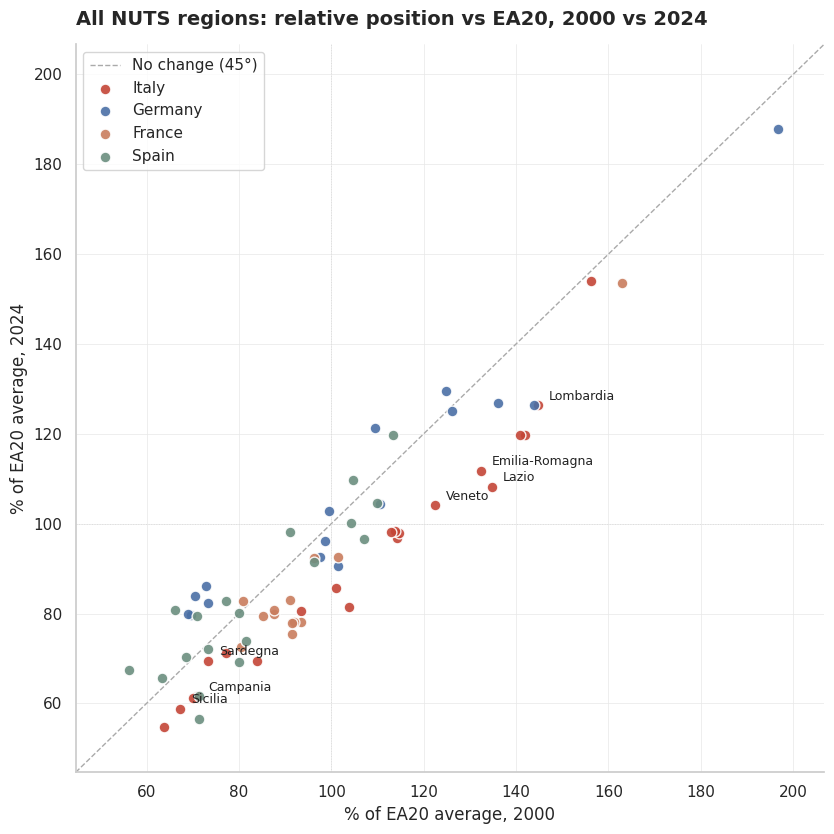

In [9]:
COLOR_BY_COUNTRY = {
    "Italy": "#c44536", "Germany": "#4a6fa5", "France": "#c97c5d", "Spain": "#6b8e7f",
}

fig, ax = plt.subplots(figsize=(8.5, 8.5))

# Reference grid: 45° diagonal = "no change vs EA20"; lines at 100 = EA20 average level
lim_min = max(0, change_table[["y2000", "y2024"]].min().min() - 10)
lim_max = change_table[["y2000", "y2024"]].max().max() + 10
lims = [lim_min, lim_max]
ax.plot(lims, lims, color="#aaa", lw=1, ls="--", zorder=1, label="No change (45°)")
ax.axhline(100, color="#ddd", lw=0.7, ls=":", zorder=1)
ax.axvline(100, color="#ddd", lw=0.7, ls=":", zorder=1)

for country in countries_in_scope:
    sub = change_table[change_table["country"] == country]
    ax.scatter(sub["y2000"], sub["y2024"],
               s=60, alpha=0.9, color=COLOR_BY_COUNTRY[country],
               edgecolor="white", linewidth=1.0, label=country, zorder=3)

italian_to_label = ["Lombardia", "Emilia-Romagna", "Veneto", "Lazio", "Sicilia", "Campania", "Sardegna"]
for _, r in change_table[change_table["region"].isin(italian_to_label)].iterrows():
    ax.annotate(r["region"], (r["y2000"], r["y2024"]),
                xytext=(8, 4), textcoords="offset points",
                fontsize=9, color="#222")

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("% of EA20 average, 2000")
ax.set_ylabel("% of EA20 average, 2024")
ax.set_title("All NUTS regions: relative position vs EA20, 2000 vs 2024",
             loc="left", fontsize=14, pad=14)
ax.legend(frameon=True, loc="upper left", facecolor="white", edgecolor="#ccc")
ax.grid(color="#e8e8e8", lw=0.5)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
plt.show()

## 10. EDA — pair-by-pair time series (% EA20)

Each subplot is one of the five narrative pairs, plotted in % of EA20 average from 2000 to 2024. The horizontal reference at 100 is the EA20 average; the shaded band shows the gap between Italian region (red) and peer (grey). The plot reveals **when** the gap opens — gradual drift, single break, or accumulating after a specific shock year (2008, 2011, 2020).

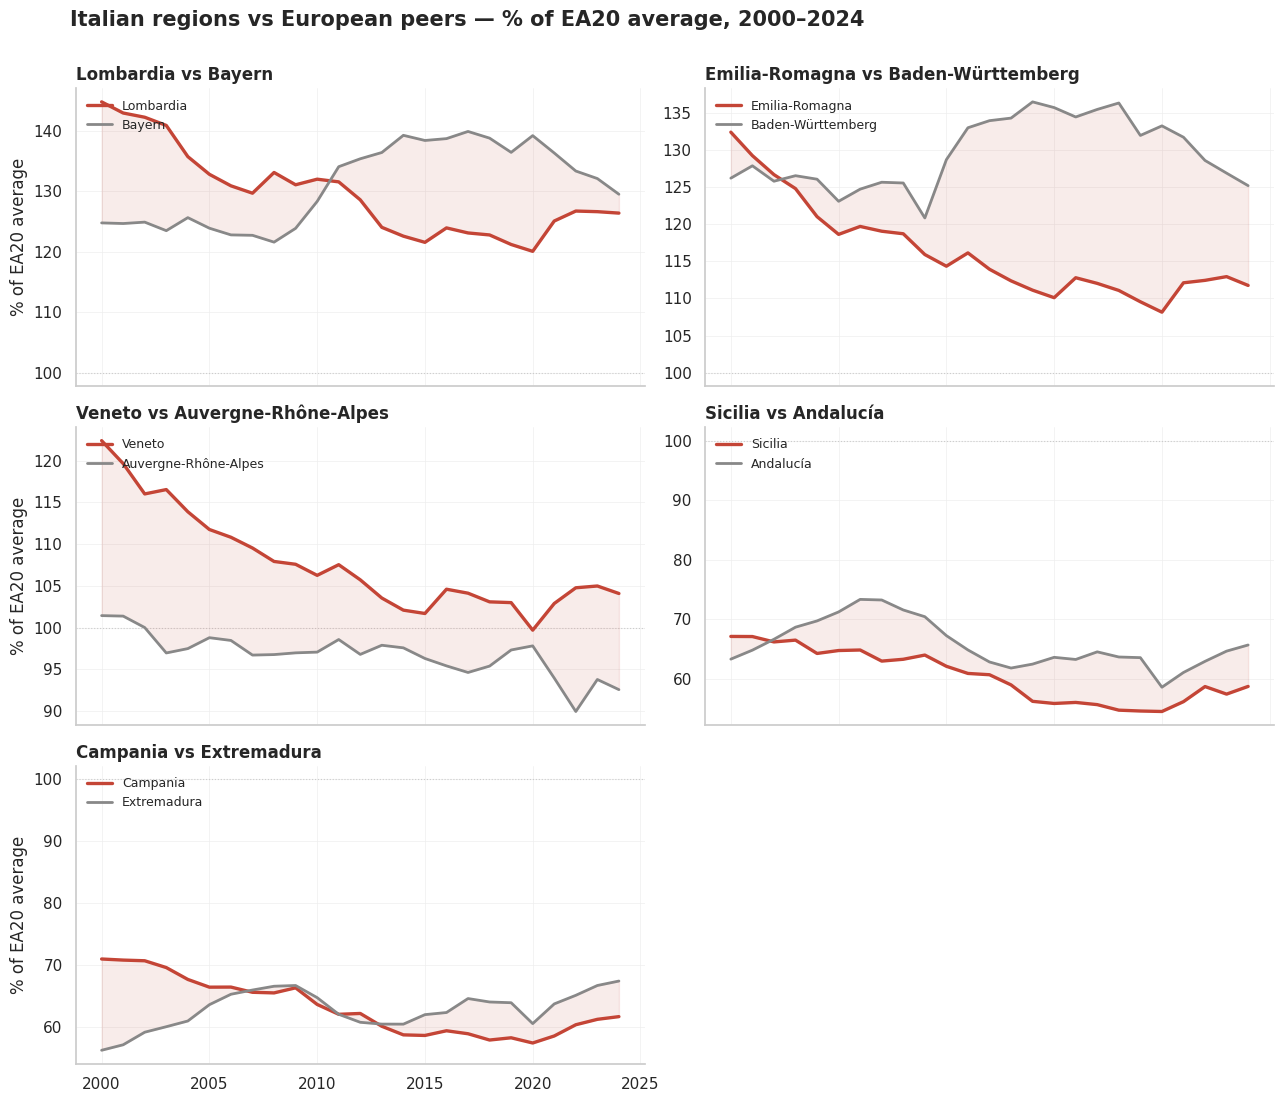

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
axes = axes.flatten()

for ax, (_, r) in zip(axes, pairs.iterrows()):
    it = regions[regions["code"] == r["italian_code"]].sort_values("year")
    pe = regions[regions["code"] == r["peer_code"]].sort_values("year")

    ax.axhline(100, color="#ccc", lw=0.8, ls=":", zorder=1)
    ax.plot(it["year"], it["pct_ea20"], color="#c44536", lw=2.4, label=r["italian_region"], zorder=3)
    ax.plot(pe["year"], pe["pct_ea20"], color="#888", lw=2.0, label=r["peer_region"], zorder=3)
    pe_aligned = pe.set_index("year").reindex(it["year"])["pct_ea20"].values
    ax.fill_between(it["year"], it["pct_ea20"], pe_aligned,
                    color="#c44536", alpha=0.10, zorder=2)

    ax.set_title(f"{r['italian_region']} vs {r['peer_region']}", fontsize=12, loc="left")
    ax.legend(fontsize=9, frameon=False, loc="upper left")
    ax.grid(color="#eee", lw=0.5)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("% of EA20 average")

if len(axes) > len(pairs):
    axes[-1].axis("off")

plt.suptitle("Italian regions vs European peers — % of EA20 average, 2000–2024",
             fontsize=15, weight="bold", y=1.00, x=0.06, ha="left")
plt.tight_layout()
plt.show()

## 11. EDA findings

### Q1: How many Italian regions show a negative Δpp?

The bar chart in section 7 and the count printed at the bottom of section 6 show that the great majority of Italian NUTS-2 regions grew more slowly than the European reference between 2000 and 2024. Bolzano is the only Italian region that essentially matches the European pace; the other twenty regions are below it. The pattern is national, not regional.

### Q2: How does Italy compare with Germany, France, and Spain?

The boxplot in section 8 shows that Italy has the most negative country median Δpp of the four. German regions cluster close to the European average; French regions split between Île-de-France (positive) and the rest (around average); Spanish regions are mostly positive. The Italian under-performance is country-wide, not concentrated in a few regions.

### Q3: Do the five narrative pairs show consistent divergence?

Yes. Every Italian region in the sanity-check pairs of section 5 ends 2024 below its German, French, or Spanish twin in the timeseries of section 10. The most striking inversion is Lombardia versus Bayern: Lombardia, the Italian economic engine, lost ground to Bayern by approximately twenty-six percentage points over the window. The divergence is the clearest editorial point in the figure.

### Verdict

The hypothesis that "the wage and income stagnation is not a Mezzogiorno-only problem" is confirmed. The slowest-growing Italian region is in the centre of the country, not in the South. Twenty of twenty-one regions grew below the European reference. The Italian under-performance is structural and national, and that is the message of the published choropleth in Figure 2.


In [11]:
# No file save: the pct_ea20 normalisation lives in memory only.
# The Tableau choropleth reads the absolute panel_t2_regional_gdp_2000_2024.csv
# (built in cell 3) and computes the % of EA20 inside the workbook itself.
print(f"In-memory pct_ea20 panel: {panel.shape}")


In-memory pct_ea20 panel: (1750, 7)
